[False False False  True False  True False False False False  True  True
  True False False  True  True False False  True  True  True  True  True
  True False False False  True False  True False False  True False False
  True False False False False False  True  True  True  True  True  True
 False  True  True False False  True False False  True False  True False
  True False  True  True False  True  True  True  True False  True  True
  True  True False False False  True False  True False False False False
  True False False  True  True False False False  True  True False  True
  True False  True  True]


C:\Users\91974\AppData\Local\Temp\ipykernel_6692\2005353516.py:28: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[mask,0],X_new[mask,1],X_new[mask,2],c='b',cmap=mglearn.cm2,s=60)
C:\Users\91974\AppData\Local\Temp\ipykernel_6692\2005353516.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[~mask,0],X_new[~mask,1],X_new[~mask,2],c='r',cmap=mglearn.cm2,s=60)


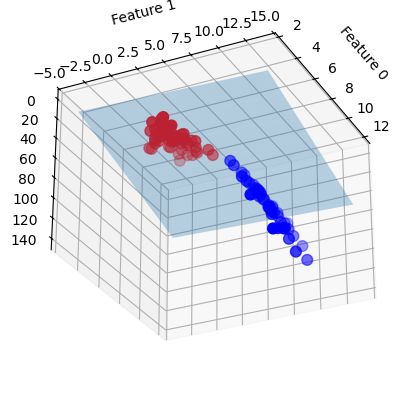

In [2]:
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import mglearn
from sklearn.datasets import make_blobs

X,Y=make_blobs(centers=2,random_state=8)
Y=Y%2

from sklearn.svm import LinearSVC
linear_svm=LinearSVC().fit(X,Y)

X_new=np.hstack([X,(X[:,1:]**2)])
linear_svm_3d=LinearSVC().fit(X_new,Y)

coef,intercept=linear_svm_3d.coef_.ravel(),linear_svm_3d.intercept_

figure=plt.figure()
ax=figure.add_subplot(111,projection='3d',elev=152,azim=-26)
XX=np.linspace(X_new[:,0].min()-2,X_new[:,0].max()+2,50)
YY=np.linspace(X_new[:,1].min()-2,X_new[:,1].max()+2,50)
XX,YY=np.meshgrid(XX,YY)

ZZ=(-coef[0]*XX-coef[1]*YY-intercept)/coef[2]
ax.plot_surface(XX,YY,ZZ,rstride=8,cstride=8,alpha=0.3)
mask=Y==0
print(mask)
ax.scatter(X_new[mask,0],X_new[mask,1],X_new[mask,2],c='b',cmap=mglearn.cm2,s=60)
ax.scatter(X_new[~mask,0],X_new[~mask,1],X_new[~mask,2],c='r',cmap=mglearn.cm2,s=60)

ax.set_xlabel("Feature 0")
ax.set_ylabel("Feature 1")
ax.set_zlabel("Feature 1**2")
plt.show()
